In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import Planetoid

c:\Users\anand\Desktop\Research Topic Classification GNN Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load CORA Dataset

In [2]:
dataset = Planetoid(root="data/Planetoid", name="Cora")

In [3]:
data = dataset[0]

print(f"Number of nodes(Research Papers): {data.num_nodes}")
print(f"Number of edges(Citations): {data.num_edges}")
print(f"Number of features per paper: {data.num_features}")
print(f"Labels per paper: {dataset.num_classes}")


print(f"Training papers: {data.train_mask.sum()}")
print(f"Validation papers: {data.val_mask.sum()}")
print(f"Testing papers: {data.test_mask.sum()}")

Number of nodes(Research Papers): 2708
Number of edges(Citations): 10556
Number of features per paper: 1433
Labels per paper: 7
Training papers: 140
Validation papers: 500
Testing papers: 1000


<Axes: xlabel='None', ylabel='count'>

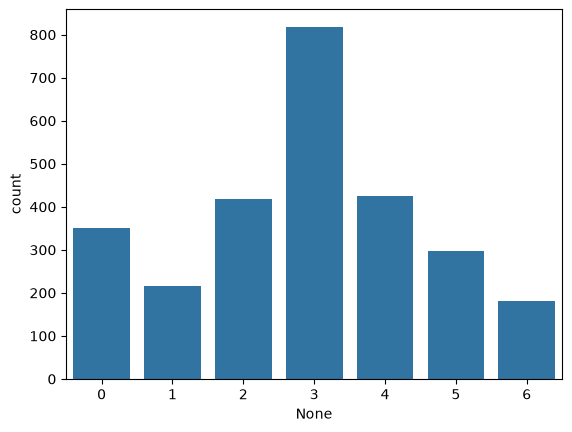

In [4]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

indexes = topic_counts.index

sns.barplot(x=indexes, y=topic_counts)

In [5]:
X_binary = data.x.numpy()
y = data.y.numpy()

Creating a baseline model of Random Forest

In [6]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.numpy()
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()


X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx], y[test_idx]

In [7]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)
random_forest_pred = random_forest.predict(X_test)

In [8]:
# Evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

rf_accuracy = accuracy_score(y_test, random_forest_pred)*100
rf_f1 = f1_score(y_test, random_forest_pred, average="macro")*100

print(f"Random Forest Accuracy Score: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")

Random Forest Accuracy Score: 58.1000
Random Forest F1 Score: 56.9807


<Axes: >

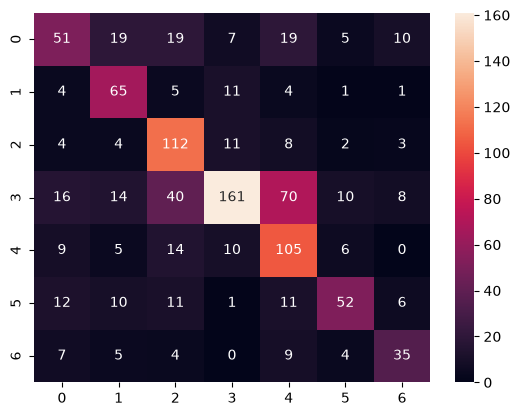

In [9]:
sns.heatmap(confusion_matrix(y_test, random_forest_pred), annot=True, fmt="d")

Create SimpleGCN 

In [10]:
from torch import nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as f

class SimpleGCN(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
    super().__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 =GCNConv(hidden_dim, output_dim)
    self.dropout = dropout
  
  def forward(self, x, edge_idx):
    x = self.conv1(x, edge_idx)
    x = f.relu(x)
    x = f.dropout(x, p=self.dropout, training=self.training)
    x = self.conv2(x, edge_idx)
    return x

In [11]:
import torch

model = SimpleGCN(
  input_dim=data.num_features,
  hidden_dim=32,
  output_dim=dataset.num_classes
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [12]:
# Training one epoch for SimpleGCN

def train_one_epoch():
  model.train()
  optimizer.zero_grad()
  logits = model(data.x, data.edge_index) # Giving the model its feature(data.x) and features from its neighbors(data.edge_index)
  
  # print(logits[0])
  # print(logits[0].argmax())
  
  loss = f.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  # print(f"Loss: {loss}")
  return loss.item()

train_one_epoch()

1.940389633178711

In [16]:
@torch.no_grad()
def evaluate(mask):
    model.eval()

    # Get model predictions for all nodes
    logits = model(data.x, data.edge_index)

    # Keep only predictions for the selected nodes
    predictions = logits[mask].argmax(dim=1)

    # Keep only the true labels for the selected nodes
    true_labels = data.y[mask]

    # Calculate accuracy
    accuracy = (predictions == true_labels).float().mean().item()

    # Calculate macro F1
    macro_f1 = f1_score(
        true_labels.cpu().numpy(),
        predictions.cpu().numpy(),
        average="macro"
    )

    return accuracy, macro_f1, predictions

In [20]:
losses, train_accuracies, validation_accuracies = [], [], []
best_validation_accuracy = 0.0
best_state = None

patience =20 # Stop training after 20 epoches if no improvement found
epoch_without_improvement = 0

for epoch in range(1, 201):
  loss = train_one_epoch()
  train_accuracy, _, _ = evaluate(data.train_mask)
  val_accuracy, _, _ = evaluate(data.val_mask)
  
  losses.append(loss)
  train_accuracies.append(train_accuracy)
  validation_accuracies.append(val_accuracy)
  
  if val_accuracy > best_validation_accuracy:
    best_validation_accuracy = val_accuracy
    best_state = model.state_dict()
    epoch_without_improvement = 0
  else:
    epoch_without_improvement += 1
    
  if epoch_without_improvement > patience:
    print(f"Early stopping at epoch: {epoch}")
    break
    
  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Accuracy: {train_accuracy:.4f} | Validation Accuracy: {val_accuracy:.4f} | Best Validation Accuracy: {best_validation_accuracy:.4f}")
  

model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_preds = evaluate(data.test_mask)

print(f"GCN Test Accuracy: {gcn_accuracy}")
print(f"GCN Test F1: {gcn_f1}")

Epoch: 001 | Loss: 0.0007 | Train Accuracy: 1.0000 | Validation Accuracy: 0.7680 | Best Validation Accuracy: 0.7680
Epoch: 010 | Loss: 0.0004 | Train Accuracy: 1.0000 | Validation Accuracy: 0.7720 | Best Validation Accuracy: 0.7720
Epoch: 020 | Loss: 0.0002 | Train Accuracy: 1.0000 | Validation Accuracy: 0.7720 | Best Validation Accuracy: 0.7720
Early stopping at epoch: 24
GCN Test Accuracy: 0.7699999809265137
GCN Test F1: 0.7598405079880266


Compare the models

In [21]:
results = pd.DataFrame({
  "Models": ["Random Forest", "GCN"],
  "Accuracy": [rf_accuracy, gcn_accuracy],
  "F1 Score": [rf_f1, gcn_f1]
})

print(results)

          Models  Accuracy   F1 Score
0  Random Forest     58.10  56.980694
1            GCN      0.77   0.759841


<Axes: >

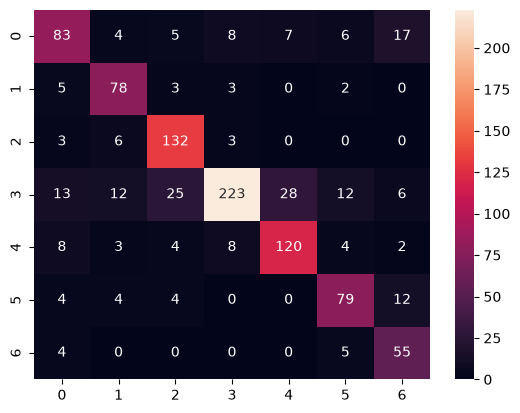

In [25]:
# Confusion Matrix for GCN
sns.heatmap(confusion_matrix(data.y[data.test_mask].numpy(), gcn_preds), annot=True, fmt="d")

Exporting Models using ONNX - Open Neural Network Exchange -> An optimized and a fast model to export deep learning models.

In [28]:
# set the model to evaluation mode
model.eval()

# create dummy input for onnx export
x_dummy = data.x  ## [num_nodes, num_features]
edge_index_dummy = data.edge_index

file_path = "simple_gcn_cora.onnx"

torch.onnx.export(
  # 1. Trained model
  model,
  
  # 2. Model inputs
  (x_dummy, edge_index_dummy),
  
  # 3. Location to save model
  f=file_path,
  
  # 4. Store trained parameter weights inside the model file
  export_params=True,
  
  # 5. Changed opset_version to 18(avoids version conversion issues)
  opset_version=18,
  
  # 6. Whether to execute constant folding for optimization
  do_constant_folding=True,
  
  # 7. Input names
  input_names =["node_features", "edge_indices"],

  # 8. Output names
  output_names=["logits"],
  
  dynamic_axes={
    "node_features": {0:"num_nodes"}, # 9. Variable length for num_nodes
    "edge_indices": {1:"num_edges"} # 10. Variable length for num_edges
  },
)

print(f"Model {model} exported to {file_path}")

C:\Users\anand\AppData\Local\Temp\ipykernel_8420\1864129686.py:10: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0907 12:43:47.080000 8420 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0907 12:43:47.094000 8420 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0907 12:43:47.095000 8420 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool
W0907 12:43:47.097000 8420 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
) exported to simple_gcn_cora.onnx
